# Paper figures & numbers — matching pipeline and descriptive results

Regenerates **every figure and every number** the paper uses in
Section 4.1 (*Geolocating Redispatch Events*) and Section 5.1 (*Redispatch Events*),
from a single source of truth, so each claim in the text can be checked against
the value printed here.

Not covered (deliberately): the scoring method (4.2), the PyPSA benchmark (4.3),
and Results 5.2/5.3 — those live in `battery_siting_score/` and `results/`.

**Source of truth:** `redispatch_joined.parquet` — the output of the
redispatch x plant-matcher join (`redispatch_plant_match.ipynb`, cell 11).
The high-confidence export rule is re-derived here rather than read from the CSV,
so that every count in this notebook comes from one basis.

**The three bases** that appear in the paper — keeping them apart is the whole point:

| basis | rule | n |
|---|---|---|
| `ALL` | every published redispatch record | 123,362 |
| `GEO` | joined to a matcher row *with coordinates*, **no confidence filter** | 101,793 |
| `EXPORT` | joined **and** `final_confidence > 0.5` **and** reason filter | 83,716 |

`EXPORT` is the analysis dataset. Several figures in the current draft were
drawn on `GEO` or on `confidence > 0.5 without the reason filter` — every cell
below states which basis it uses.

Figures are written to `figures_paper/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_DIR = Path('.').resolve()
FIG_DIR  = DATA_DIR / 'figures_paper'
FIG_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

CARRIER_COLORS = {'Konventionell': '#cc4b3a', 'Erneuerbar': '#3aa856', 'Sonstiges': '#888'}
TSO_COLORS     = {'50Hertz': '#3a6ea5', 'Amprion': '#e09d3c',
                  'TenneT DE': '#cc4b3a', 'TransnetBW': '#6abf69'}
REGION_ORDER   = ['North', 'Centre', 'South']
REGION_COLORS  = {'North': '#3a6ea5', 'Centre': '#e09d3c', 'South': '#cc4b3a'}
DIR_COLORS     = {'up': '#e09d3c', 'down': '#3a6ea5'}

# Collects every checkable claim; rendered as a table in the last section.
CLAIMS = []
def _tol(paper):
    # Tolerance = half of the last decimal the paper prints, so 13.7 vs 13.73 passes
    # but 36,801 vs 39,646 does not.
    s = str(paper)
    return 0.5 * 10 ** -len(s.split('.')[1]) if '.' in s else 0.5

def claim(section, what, paper, computed, ok=None, note=''):
    if ok is None:
        try:
            ok = abs(float(paper) - float(computed)) <= _tol(paper)
        except (TypeError, ValueError):
            ok = str(paper) == str(computed)
    CLAIMS.append({'section': section, 'claim': what, 'paper': paper,
                   'computed': computed, 'ok': bool(ok), 'note': note})
    return ok

def save(fig, name):
    p = FIG_DIR / f'{name}.png'
    fig.savefig(p, bbox_inches='tight')
    print(f'  saved {p.relative_to(DATA_DIR)}')
    return p

def thousands(ax, axis='y'):
    f = FuncFormatter(lambda v, _: f'{v:,.0f}')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)

---
## 1. Load and define the three bases

In [2]:
joined = pd.read_parquet(DATA_DIR / 'redispatch_joined.parquet')

# _merge=='both' was dropped when the parquet was written; plant_name is its proxy.
matched = joined['plant_name'].notna()

reason = joined['GRUND_DER_MASSNAHME'].astype(str)
reason_ok = (reason.str.contains('bedingt', case=False, na=False)
             & ~reason.str.contains('countertrade', case=False, na=False))

joined['basis_geo']    = matched & joined['lat'].notna()                    # 101,793
joined['basis_conf']   = matched & (joined['final_confidence'] > 0.5)       #  86,561
joined['basis_export'] = joined['basis_conf'] & reason_ok                   #  83,716

ALL    = joined
GEO    = joined[joined['basis_geo']]
EXPORT = joined[joined['basis_export']]

vol = lambda d: d['GESAMTE_ARBEIT_MWH'].abs().sum()

print(f'ALL     {len(ALL):>7,} events   {vol(ALL)/1e6:7.2f} TWh   '
      f'{ALL.ts_start.min().date()} -> {ALL.ts_start.max().date()}')
print(f'GEO     {len(GEO):>7,} events   {vol(GEO)/1e6:7.2f} TWh')
print(f'EXPORT  {len(EXPORT):>7,} events   {vol(EXPORT)/1e6:7.2f} TWh')

claim('4',   'total events',            123362, len(ALL))
claim('4',   'total volume (TWh, abs)', 182.03, round(vol(ALL)/1e6, 2))
claim('4',   'data end date',    '2026-06-22', str(ALL.ts_start.max().date()))
claim('4.1', 'events kept',              83716, len(EXPORT))
claim('4.1', 'share of events kept (%)',  67.9, round(100*len(EXPORT)/len(ALL), 1))
claim('4.1', 'volume kept (TWh)',        120.6, round(vol(EXPORT)/1e6, 1))
claim('4.1', 'share of volume kept (%)',  66.3, round(100*vol(EXPORT)/vol(ALL), 1))

ALL     123,362 events    182.03 TWh   2013-04-02 -> 2026-06-22
GEO     101,793 events    139.01 TWh
EXPORT   83,716 events    120.60 TWh


True

### 1a. Filter waterfall

The step the current draft loses track of is the **reason filter**: it removes 2,845
events that were matched *with high confidence* (mean 0.97) but are test runs
(`Probefahrt`, `Testfahrt (bnBm)`, `Probestart (NetzRes)`, `Funktionstest`, ...)
plus one countertrade batch. Because Figure 5 in the draft is drawn before this step,
its "36,801 excluded" does not reconcile with "83,716 kept" (123,362 - 83,716 = 39,646).

,step,events,d_events,% of all,TWh
0,all published events,123362,0,100.0,182.03
1,joined to a matcher row,105668,-17694,85.7,144.20
2,... with coordinates [GEO],101793,-3875,82.5,139.01
3,... confidence > 0.5,86561,-15232,70.2,123.11
4,... reason filter [EXPORT],83716,-2845,67.9,120.60



removed by the reason filter alone: 2,845 events, mean confidence 0.97
GRUND_DER_MASSNAHME
Testfahrt (bnBm)                                        775
Probestart (NetzRes)                                    670
Probefahrt                                              543
Testfahrt (KapRes)                                      535
Probeabruf (KapRes)                                      92
Gezielter Leistungsausgleich bei Einspeisemanagement     87
Funktionstest (KapRes)                                   58
Strombedingter Countertrade DE-DK1                       57
Funktionstest (bnBm)                                     14
Probeabruf (bnBm)                                         6


  saved figures_paper\F1_filter_waterfall.png


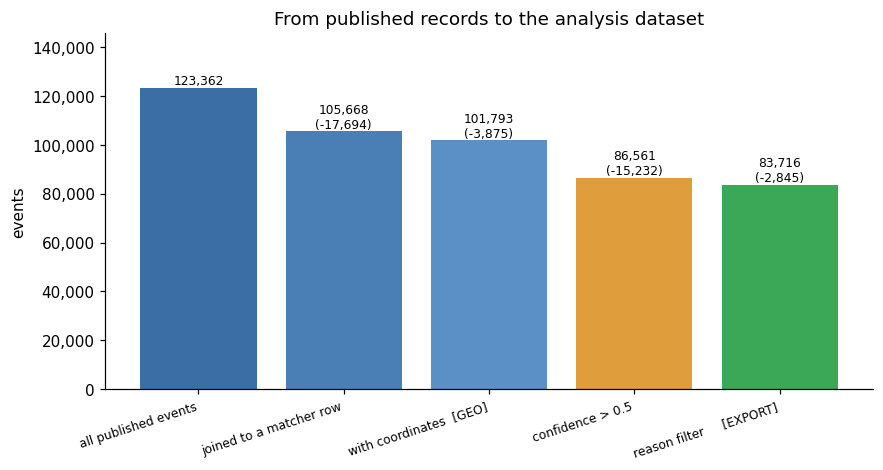

In [3]:
steps = [
    ('all published events',            len(ALL),                        vol(ALL)),
    ('joined to a matcher row',         int(matched.sum()),              vol(joined[matched])),
    ('... with coordinates  [GEO]',     len(GEO),                        vol(GEO)),
    ('... confidence > 0.5',            int(joined['basis_conf'].sum()), vol(joined[joined['basis_conf']])),
    ('... reason filter     [EXPORT]',  len(EXPORT),                     vol(EXPORT)),
]
wf = pd.DataFrame(steps, columns=['step', 'events', 'MWh'])
wf['TWh']       = (wf['MWh'] / 1e6).round(2)
wf['d_events']  = wf['events'].diff().fillna(0).astype(int)
wf['% of all']  = (100 * wf['events'] / len(ALL)).round(1)
display(wf[['step', 'events', 'd_events', '% of all', 'TWh']])

lost = joined[joined['basis_conf'] & ~reason_ok]
print(f'\nremoved by the reason filter alone: {len(lost):,} events, '
      f'mean confidence {lost.final_confidence.mean():.2f}')
print(lost['GRUND_DER_MASSNAHME'].value_counts().head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(len(wf)), wf['events'], color=['#3a6ea5','#4a7fb5','#5a90c5','#e09d3c','#3aa856'])
for i, (n, d) in enumerate(zip(wf['events'], wf['d_events'])):
    lab = f'{n:,}' + (f'\n({d:+,})' if i else '')
    ax.annotate(lab, (i, n), ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(wf)))
ax.set_xticklabels([s.replace('... ', '') for s in wf['step']], rotation=18, ha='right', fontsize=8)
ax.set_ylabel('events'); ax.set_ylim(0, wf['events'].max()*1.18)
ax.set_title('From published records to the analysis dataset')
thousands(ax)
save(fig, 'F1_filter_waterfall'); plt.show()

---
## 2. Confidence distribution  — paper Figure 4  *(basis: ALL)*

The draft's bucket counts are correct. The only thing to fix is the sentence
"roughly three quarters of **all events** were matched with confidence above 0.8":
76,769 is 62% of all 123,362 records, but 73% of the 105,668 that received a match.

final_confidence
(0, 0.2]        6986
(0.2, 0.4]      7568
(0.4, 0.5]      4553
(0.5, 0.6]      1740
(0.6, 0.8]      8052
(0.8, 0.95]    20553
(0.95, 1.0]    56216

unmatched (no confidence): 17,694

confidence > 0.8 : 76,769  = 62% of ALL events  |  73% of the 105,668 matched events


  saved figures_paper\F2_confidence_distribution.png


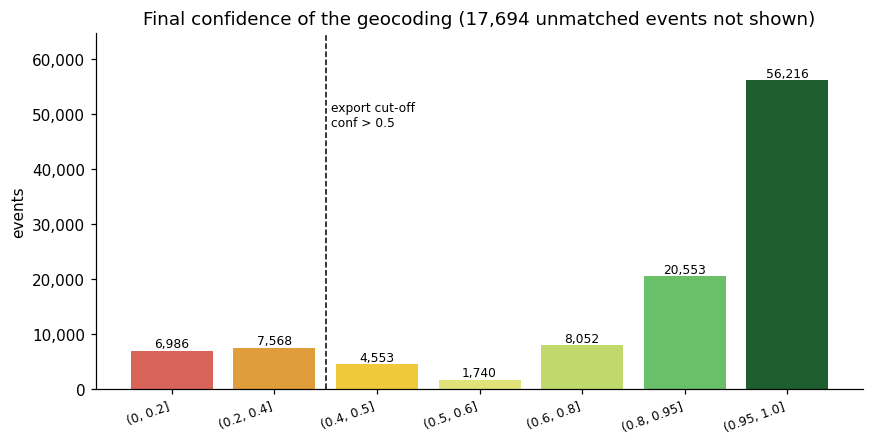

In [4]:
bins   = [-0.001, 0.2, 0.4, 0.5, 0.6, 0.8, 0.95, 1.0]
labels = ['(0, 0.2]', '(0.2, 0.4]', '(0.4, 0.5]', '(0.5, 0.6]', '(0.6, 0.8]', '(0.8, 0.95]', '(0.95, 1.0]']
conf_b = pd.cut(ALL['final_confidence'], bins=bins, labels=labels)
dist   = conf_b.value_counts().reindex(labels)
n_unmatched = int(ALL['final_confidence'].isna().sum())

print(dist.to_string())
print(f'\nunmatched (no confidence): {n_unmatched:,}')

n_hi   = int(dist['(0.8, 0.95]'] + dist['(0.95, 1.0]'])
n_mtch = int(ALL['final_confidence'].notna().sum())
print(f'\nconfidence > 0.8 : {n_hi:,}  = {100*n_hi/len(ALL):.0f}% of ALL events'
      f'  |  {100*n_hi/n_mtch:.0f}% of the {n_mtch:,} matched events')

claim('4.1', 'events in (0.95, 1.0]', 56216, int(dist['(0.95, 1.0]']))
claim('4.1', 'events in (0.8, 0.95]', 20553, int(dist['(0.8, 0.95]']))
claim('4.1', '"three quarters" with conf > 0.8', '75% of all events',
      f'{100*n_hi/len(ALL):.0f}% of all / {100*n_hi/n_mtch:.0f}% of matched',
      ok=False, note='denominator must be stated: 62% of all, 73% of matched')

colors = ['#d96459', '#e09d3c', '#f0c93b', '#dfe37a', '#bfd96b', '#6abf69', '#1f5e2e']
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(len(dist)), dist.values, color=colors)
for i, v in enumerate(dist.values):
    ax.annotate(f'{int(v):,}', (i, v), ha='center', va='bottom', fontsize=8)
ax.axvline(1.5, color='k', ls='--', lw=1)
ax.annotate('export cut-off\nconf > 0.5', (1.55, dist.max()*0.85), fontsize=8)
ax.set_xticks(range(len(dist))); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('events'); ax.set_ylim(0, dist.max()*1.15)
ax.set_title(f'Final confidence of the geocoding ({n_unmatched:,} unmatched events not shown)')
thousands(ax)
save(fig, 'F2_confidence_distribution'); plt.show()

---
## 3. Which source resolved the match — paper Figure 7  *(basis: ALL)*

,events
geocode_source,
opsd_exact,50493
None,17694
wikipedia,10168
psa_exact,9278
nominatim,5689
manual,4748
unresolved,4595
psa_fuzzy,4547
gazetteer,4535


  saved figures_paper\F3_geocode_source.png


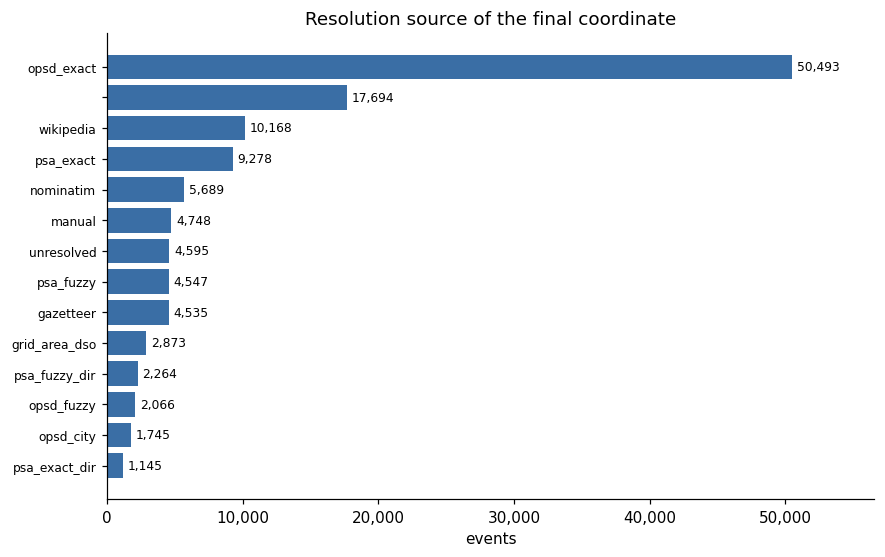

In [5]:
src = ALL['geocode_source'].value_counts(dropna=False).rename(index={np.nan: 'unmatched'})
display(src.head(20).to_frame('events'))

for k, v in [('opsd_exact', 50493), ('wikipedia', 10168), ('psa_exact', 9278)]:
    claim('4.1', f'events resolved by {k}', v, int(src.get(k, 0)))

top = src.drop(labels=[i for i in ['unmatched'] if i in src.index]).head(14)[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(range(len(top)), top.values, color='#3a6ea5')
for i, v in enumerate(top.values):
    ax.annotate(f'{int(v):,}', (v, i), va='center', ha='left', fontsize=8, xytext=(3, 0),
                textcoords='offset points')
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel('events'); ax.set_xlim(0, top.max()*1.12)
ax.set_title('Resolution source of the final coordinate')
thousands(ax, 'x')
save(fig, 'F3_geocode_source'); plt.show()

---
## 4. What gets excluded — paper Figure 5  **(corrected)**

The draft decomposes **36,801** events, which is `123,362 - 86,561`, i.e. the count
*before* the reason filter. The analysis set is 83,716, so the honest total is
**39,646**, and the missing category is the test/probe runs.

Both versions are computed below so the difference is visible.

AS IN THE DRAFT  — total 36,801 (conf <= 0.5 or unmatched)


,events,energy_gwh,share
drop_class,,,
low-confidence match,19107,21089.0,52.0
market,15236,28580.0,41.0
multi-plant bundle,2316,8949.0,6.0
other,142,303.0,0.0


CORRECTED        — total 39,646 (everything the analysis set drops)


,events,energy_gwh,share
drop_class,,,
low-confidence match,19107,21089.0,48.0
market,15236,28580.0,38.0
test / probe run,2788,2472.0,7.0
multi-plant bundle,2316,8949.0,6.0
other,142,303.0,0.0
market (countertrade),57,39.0,0.0


  saved figures_paper\F4_exclusions_corrected.png


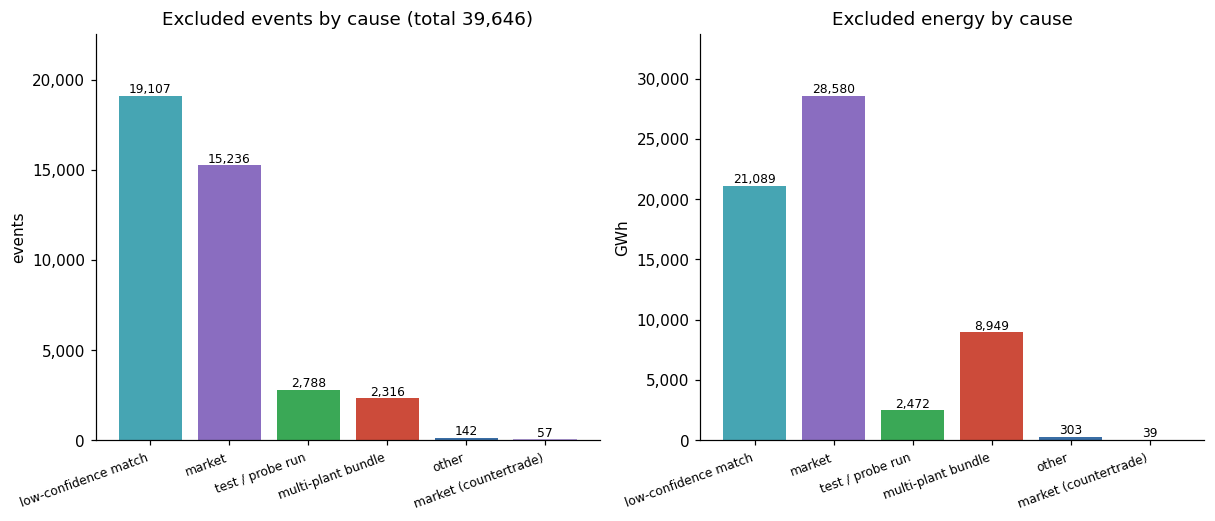

In [6]:
def classify_unmatched(name):
    # Classifier from redispatch_plant_match.ipynb cell 37, unchanged.
    if not isinstance(name, str):
        return 'other'
    low = name.lower()
    if low.startswith('börse') or low.startswith('b�rse') or 'trading' in low \
       or 'bilanzkreis' in low or 'handel' in low:
        return 'market'
    if ',' in name:
        return 'multi-plant bundle'
    if any(t in name for t in ['(KapRes)', '(NetzRes)', '(bnBm)']):
        return 'reserve label'
    return 'other'

def decompose(dropped, with_reason_category):
    d = dropped.copy()
    is_m = d['plant_name'].notna()
    cls = np.where(is_m, 'low-confidence match',
                   d['BETROFFENE_ANLAGE'].map(classify_unmatched))
    if with_reason_category:
        rf = d['basis_conf'].values          # matched + confident, removed by reason filter
        ct = d['GRUND_DER_MASSNAHME'].astype(str).str.contains('countertrade', case=False).values
        cls = np.where(rf & ct,  'market (countertrade)',
              np.where(rf,       'test / probe run', cls))
    d['drop_class'] = cls
    out = (d.groupby('drop_class')
             .agg(events=('GRUND_DER_MASSNAHME', 'size'),
                  energy_gwh=('GESAMTE_ARBEIT_MWH', lambda s: s.abs().sum()/1e3))
             .sort_values('events', ascending=False))
    out['share'] = (100 * out['events'] / out['events'].sum()).round(1)
    return out.round(0)

old = decompose(joined[~joined['basis_conf']], with_reason_category=False)
new = decompose(joined[~joined['basis_export']], with_reason_category=True)

print(f'AS IN THE DRAFT  — total {int(old["events"].sum()):,} (conf <= 0.5 or unmatched)')
display(old)
print(f'CORRECTED        — total {int(new["events"].sum()):,} (everything the analysis set drops)')
display(new)

claim('4.1', 'excluded events', 36801, int(new['events'].sum()), ok=False,
      note='36,801 is the pre-reason-filter count; 123,362-83,716 = 39,646')
claim('4.1', 'low-confidence matches', 19107, int(new.loc['low-confidence match', 'events']))
claim('4.1', 'market-based measures',  15236, int(new.loc['market', 'events']))
claim('4.1', 'multi-plant bundles',     2316, int(new.loc['multi-plant bundle', 'events']))
claim('4.1', 'dropped market volume (GWh)', 28580, int(new.loc['market', 'energy_gwh']))

cls_colors = {'market': '#8a6dc0', 'multi-plant bundle': '#cc4b3a', 'reserve label': '#e09d3c',
              'other': '#3a6ea5', 'low-confidence match': '#46a5b3',
              'test / probe run': '#3aa856', 'market (countertrade)': '#b09ad6'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, col, lab in [(axes[0], 'events', 'events'), (axes[1], 'energy_gwh', 'GWh')]:
    ax.bar(range(len(new)), new[col], color=[cls_colors.get(c, '#888') for c in new.index])
    for i, v in enumerate(new[col]):
        ax.annotate(f'{int(v):,}', (i, v), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(new)))
    ax.set_xticklabels(new.index, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(lab); ax.set_ylim(0, new[col].max()*1.18); thousands(ax)
axes[0].set_title(f'Excluded events by cause (total {int(new["events"].sum()):,})')
axes[1].set_title('Excluded energy by cause')
save(fig, 'F4_exclusions_corrected'); plt.show()

---
## 5. Börse / countertrade volume by TSO — paper Figure 6  *(basis: ALL)*

These numbers in the draft are correct.

ANWEISENDER_UENB
TenneT DE     13.73
TransnetBW     1.04
Amprion        0.56
50Hertz        0.40


  saved figures_paper\F5_market_volume_by_tso.png


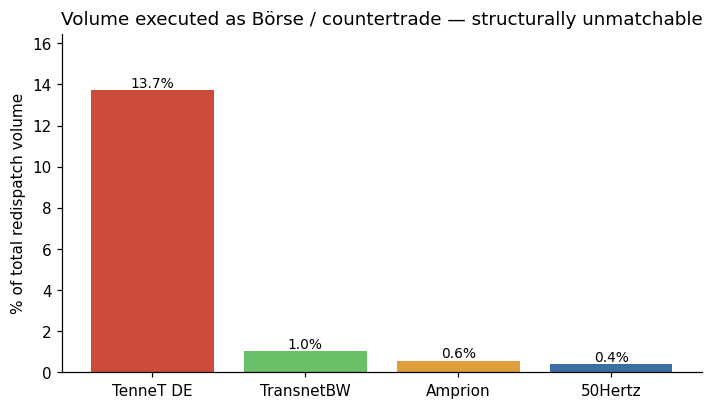

In [7]:
is_mkt = (ALL['GRUND_DER_MASSNAHME'].astype(str).str.contains('countertrade', case=False)
          | ALL['BETROFFENE_ANLAGE'].astype(str).str.contains('rse', case=False))
tot = vol(ALL)
mkt_share = (ALL[is_mkt].groupby(ALL['ANWEISENDER_UENB'].astype(str))['GESAMTE_ARBEIT_MWH']
             .apply(lambda s: 100*s.abs().sum()/tot).round(2).sort_values(ascending=False))
print(mkt_share.to_string())

for t, v in [('TenneT DE', 13.7), ('TransnetBW', 1.0), ('Amprion', 0.6), ('50Hertz', 0.4)]:
    claim('4.1', f'{t} market volume (% of total)', v, float(mkt_share.get(t, 0)))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(mkt_share.index, mkt_share.values,
       color=[TSO_COLORS.get(t, '#888') for t in mkt_share.index])
for i, v in enumerate(mkt_share.values):
    ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of total redispatch volume'); ax.set_ylim(0, mkt_share.max()*1.2)
ax.set_title('Volume executed as Börse / countertrade — structurally unmatchable')
save(fig, 'F5_market_volume_by_tso'); plt.show()

---
## 6. Match rate by ÜNB — paper Figure 8  **(basis must be stated)**

The draft's caption says `confidence > 0.5` but the text says `confidence > 0.4`, and the
printed values (Amprion 83/64/86, TransnetBW 86/71/91, 50Hertz plants 20%, TenneT 66/60)
reproduce **exactly at conf > 0.4** — so the text is right and the caption is wrong.

That still leaves a substantive problem: every other number in the paper rests on the
`EXPORT` set (conf > 0.5 **and** the reason filter), where the same rates are 5–20 pp
lower (Amprion 71/51/79, 50Hertz plants 13%). Either relabel the figure as a
*matching-pipeline* diagnostic at 0.4 and say so, or redraw it on `EXPORT`.
All three bases are computed below.

--- GEO (any match + coords) ---
            events_%  plants_%  MWh_%
50Hertz         82.0      32.0   73.0
Amprion         84.0      80.0   86.0
TenneT DE       78.0      95.0   67.0
TransnetBW      91.0      85.0   93.0

--- conf > 0.4 ---
            events_%  plants_%  MWh_%
50Hertz         70.0      20.0   60.0
Amprion         83.0      64.0   86.0
TenneT DE       66.0      82.0   60.0
TransnetBW      86.0      71.0   91.0

--- EXPORT (conf>0.5 + reason) ---
            events_%  plants_%  MWh_%
50Hertz         65.0      13.0   59.0
Amprion         71.0      51.0   79.0
TenneT DE       60.0      60.0   57.0
TransnetBW      83.0      62.0   88.0



  saved figures_paper\F6_match_rate_by_tso.png


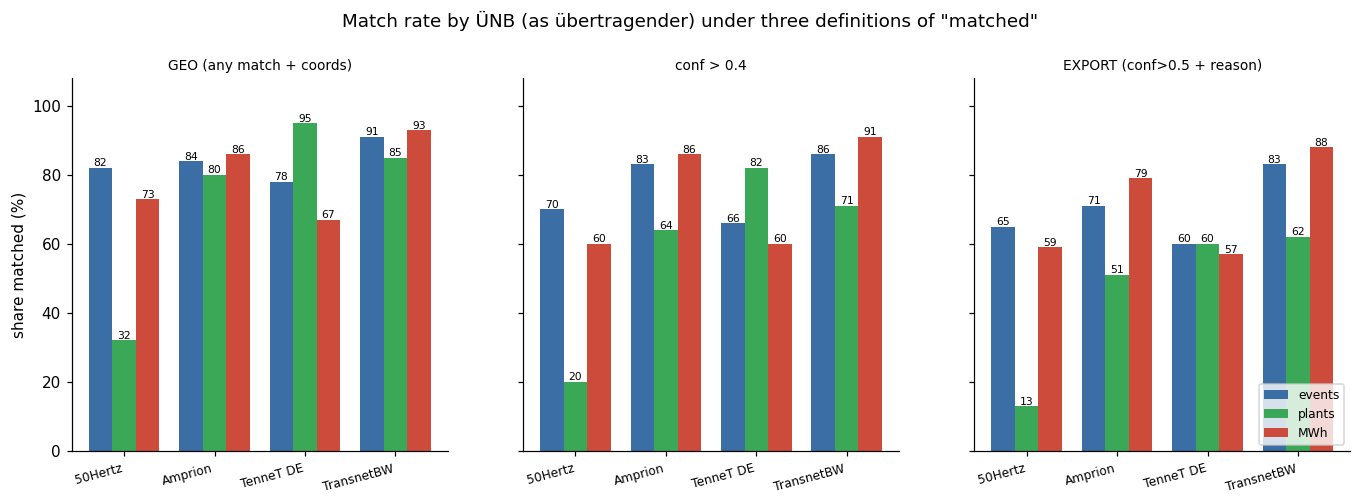

In [8]:
TSOS = ['50Hertz', 'Amprion', 'TenneT DE', 'TransnetBW']
anw  = ALL['ANWEISENDER_UENB'].fillna('')

def match_table(ok_mask):
    rows = {}
    for t in TSOS:
        sub = ALL[anw.str.contains(t, regex=False)]
        hit = sub[ok_mask.loc[sub.index]]
        rows[t] = {'events_%': 100*len(hit)/len(sub),
                   'plants_%': 100*hit['BETROFFENE_ANLAGE'].nunique()/sub['BETROFFENE_ANLAGE'].nunique(),
                   'MWh_%'   : 100*hit['GESAMTE_ARBEIT_MWH'].abs().sum()/sub['GESAMTE_ARBEIT_MWH'].abs().sum()}
    return pd.DataFrame(rows).T.round(0)

bases = {'GEO (any match + coords)': joined['basis_geo'],
         'conf > 0.4'              : matched & (joined['final_confidence'] > 0.4),
         'EXPORT (conf>0.5 + reason)': joined['basis_export']}
tables = {k: match_table(v) for k, v in bases.items()}
for k, t in tables.items():
    print(f'--- {k} ---'); print(t.to_string()); print()

ref = tables['conf > 0.4']            # the basis the printed values come from
exp = tables['EXPORT (conf>0.5 + reason)']
trio = lambda t, k: '/'.join(f'{t.loc[k, c]:.0f}' for c in ['events_%','plants_%','MWh_%'])

claim('4.1', 'Amprion events/plants/MWh %', '83/64/86', trio(ref, 'Amprion'),
      note=f'matches at conf>0.4; on EXPORT it is {trio(exp, "Amprion")}')
claim('4.1', 'TransnetBW events/plants/MWh %', '86/71/91', trio(ref, 'TransnetBW'),
      note=f'on EXPORT: {trio(exp, "TransnetBW")}')
claim('4.1', '50Hertz plants %', 20, float(ref.loc['50Hertz', 'plants_%']),
      note=f'on EXPORT: {exp.loc["50Hertz","plants_%"]:.0f}%')
claim('4.1', 'figure caption threshold', 'conf > 0.5', 'conf > 0.4', ok=False,
      note='caption and text disagree; the values are the 0.4 ones')
claim('4.1', 'TenneT "MWh and event rates (66% and 60%)"',
      'MWh 66 / events 60',
      f'events {ref.loc["TenneT DE","events_%"]:.0f} / MWh {ref.loc["TenneT DE","MWh_%"]:.0f}',
      ok=False, note='labels swapped in the text: 66 is events, 60 is MWh')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
metrics = ['events_%', 'plants_%', 'MWh_%']
mcol = {'events_%': '#3a6ea5', 'plants_%': '#3aa856', 'MWh_%': '#cc4b3a'}
for ax, (name, tbl) in zip(axes, tables.items()):
    x = np.arange(len(tbl))
    for i, m in enumerate(metrics):
        b = ax.bar(x + (i-1)*0.26, tbl[m], 0.26, label=m.replace('_%',''), color=mcol[m])
        for bb, v in zip(b, tbl[m]):
            ax.annotate(f'{v:.0f}', (bb.get_x()+bb.get_width()/2, v), ha='center',
                        va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(tbl.index, rotation=15, ha='right', fontsize=8)
    ax.set_title(name, fontsize=9); ax.set_ylim(0, 108)
axes[0].set_ylabel('share matched (%)'); axes[2].legend(fontsize=8, loc='lower right')
fig.suptitle('Match rate by ÜNB (as übertragender) under three definitions of "matched"', y=1.02)
save(fig, 'F6_match_rate_by_tso'); plt.show()

---
## 7. Region × direction — paper Figure 2  **(corrected)**

The draft's numbers (North ~27,800 down / 5,800 up, South ~25,900 up / 3,400 down,
Centre ~39,300) reproduce exactly on the **GEO** basis — 101,793 events, no confidence
filter — which is why they sum to ~102,000 rather than to 83,716.
Both bases are plotted; the north–south asymmetry is unchanged, only the levels move.

Note also that `lat_band()` cuts at 52.0 / 49.5 °N: these are **latitude bands**,
not TSO control areas, and the text should not call them "control areas".

GEO basis  (n = 101,793) — what the current Figure 2 shows


events             GWh         
dir      down     up     down       up
region                                
North   27574   5875  40124.0   8489.0
Centre  22003  17203  29432.0  22240.0
South    3347  25791   2738.0  35990.0

EXPORT basis (n = 83,716) — what it should show


events             GWh         
dir      down     up     down       up
region                                
North   21925   5206  34856.0   8340.0
Centre  17225  14587  23339.0  19600.0
South    2759  22014   2288.0  32178.0

  saved figures_paper\F7_region_direction_corrected.png


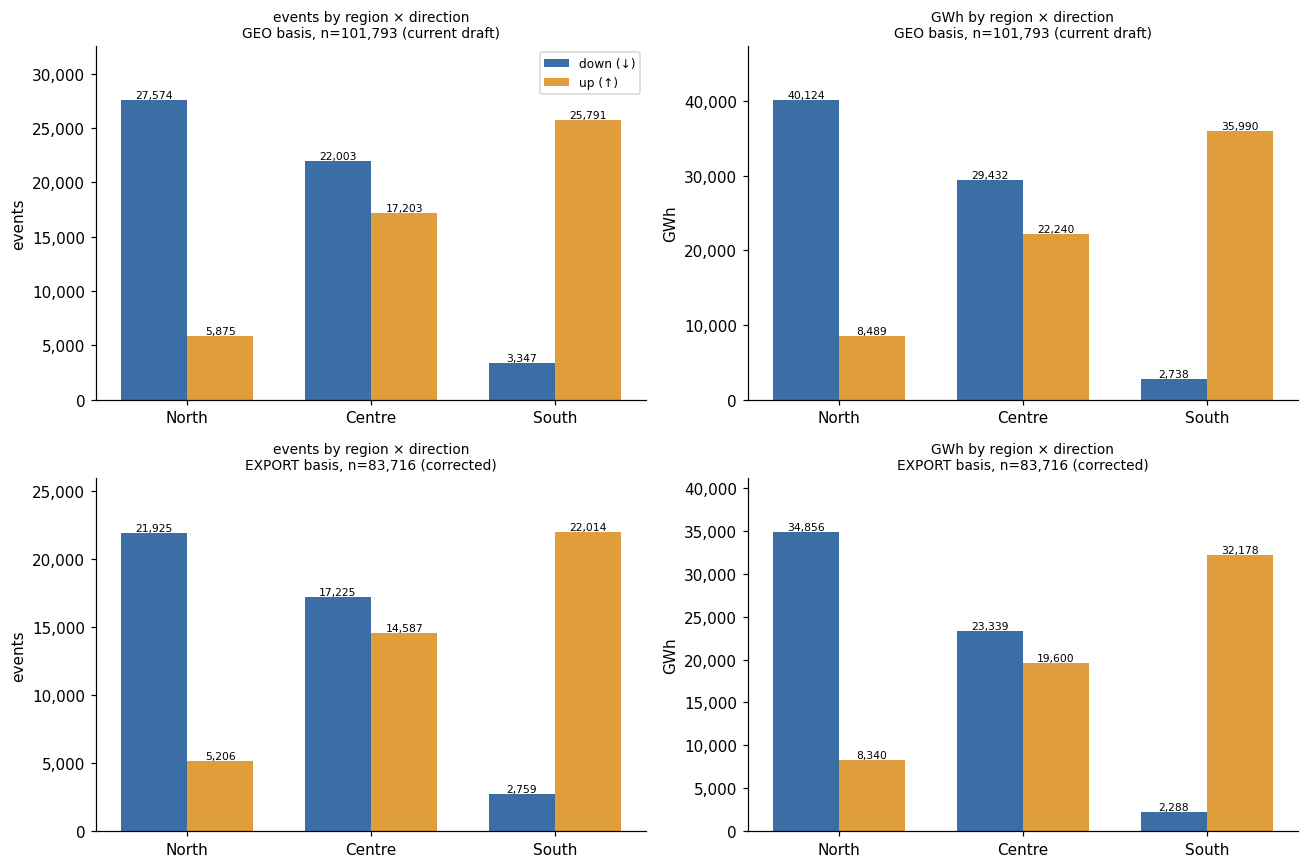

  saved figures_paper\F7b_region_direction_paper.png


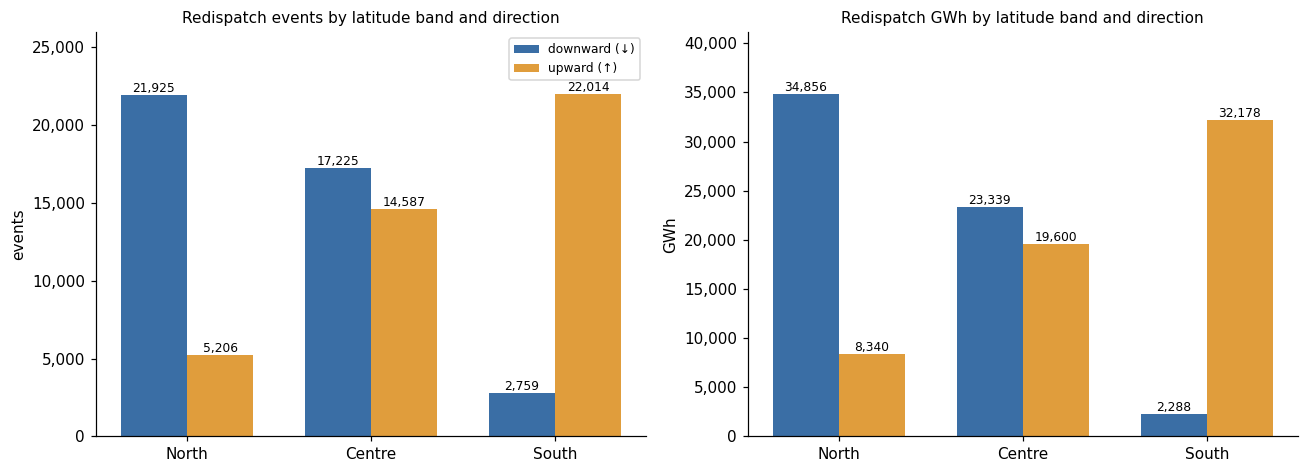

In [9]:
def lat_band(lat):
    if lat >= 52.0: return 'North'
    if lat >= 49.5: return 'Centre'
    return 'South'

def dir_short(s):
    if not isinstance(s, str): return None
    return 'up' if 'erh' in s else ('down' if 'redu' in s else None)

def region_tables(df):
    d = df.dropna(subset=['lat']).copy()
    d['region'] = d['lat'].map(lat_band)
    d['dir']    = d['RICHTUNG'].map(dir_short)
    ev = d.groupby(['region','dir']).size().unstack(fill_value=0).reindex(REGION_ORDER)[['down','up']]
    en = (d.groupby(['region','dir'])['GESAMTE_ARBEIT_MWH'].apply(lambda s: s.abs().sum())
            .unstack(fill_value=0).reindex(REGION_ORDER)[['down','up']] / 1e3).round(0)
    return ev, en

ev_geo, en_geo = region_tables(GEO)
ev_exp, en_exp = region_tables(EXPORT)

print(f'GEO basis  (n = {int(ev_geo.values.sum()):,}) — what the current Figure 2 shows')
display(pd.concat({'events': ev_geo, 'GWh': en_geo}, axis=1))
print(f'EXPORT basis (n = {int(ev_exp.values.sum()):,}) — what it should show')
display(pd.concat({'events': ev_exp, 'GWh': en_exp}, axis=1))

claim('5.1', 'North down events', 27800, int(ev_geo.loc['North','down']),
      ok=False, note=f'GEO basis; on EXPORT it is {int(ev_exp.loc["North","down"]):,}')
claim('5.1', 'North down GWh',    40000, int(en_geo.loc['North','down']),
      ok=False, note=f'EXPORT: {int(en_exp.loc["North","down"]):,}')
claim('5.1', 'North up events',    5800, int(ev_geo.loc['North','up']),
      ok=False, note=f'EXPORT: {int(ev_exp.loc["North","up"]):,}')
claim('5.1', 'South up events',   25900, int(ev_geo.loc['South','up']),
      ok=False, note=f'EXPORT: {int(ev_exp.loc["South","up"]):,}')
claim('5.1', 'South down events',  3400, int(ev_geo.loc['South','down']),
      ok=False, note=f'EXPORT: {int(ev_exp.loc["South","down"]):,}')
claim('5.1', 'regional totals sum to the analysis set', 83716,
      int(ev_geo.values.sum()), ok=False,
      note='Figure 2 currently totals 101,793')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for r, (ev, en, tag) in enumerate([(ev_geo, en_geo, f'GEO basis, n={int(ev_geo.values.sum()):,} (current draft)'),
                                   (ev_exp, en_exp, f'EXPORT basis, n={int(ev_exp.values.sum()):,} (corrected)')]):
    for c, (tbl, lab) in enumerate([(ev, 'events'), (en, 'GWh')]):
        ax = axes[r, c]; x = np.arange(len(tbl))
        for i, d in enumerate(['down', 'up']):
            b = ax.bar(x + (i-0.5)*0.36, tbl[d], 0.36, label=f'{d} ({"↓" if d=="down" else "↑"})',
                       color=DIR_COLORS[d])
            for bb, v in zip(b, tbl[d]):
                ax.annotate(f'{int(v):,}', (bb.get_x()+bb.get_width()/2, v), ha='center',
                            va='bottom', fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(tbl.index)
        ax.set_ylabel(lab); ax.set_ylim(0, tbl.values.max()*1.18); thousands(ax)
        ax.set_title(f'{lab} by region × direction\n{tag}', fontsize=9)
        if r == 0 and c == 0: ax.legend(fontsize=8)
plt.tight_layout()
save(fig, 'F7_region_direction_corrected'); plt.show()

# Corrected figure on its own, for the paper.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, (tbl, lab) in zip(axes, [(ev_exp, 'events'), (en_exp, 'GWh')]):
    x = np.arange(len(tbl))
    for i, d in enumerate(['down', 'up']):
        b = ax.bar(x + (i-0.5)*0.36, tbl[d], 0.36,
                   label='downward (↓)' if d=='down' else 'upward (↑)', color=DIR_COLORS[d])
        for bb, v in zip(b, tbl[d]):
            ax.annotate(f'{int(v):,}', (bb.get_x()+bb.get_width()/2, v), ha='center',
                        va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(tbl.index)
    ax.set_ylabel(lab); ax.set_ylim(0, tbl.values.max()*1.18); thousands(ax)
    ax.set_title(f'Redispatch {lab} by latitude band and direction', fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout()
save(fig, 'F7b_region_direction_paper'); plt.show()

---
## 8. Development over time — paper Figures 1 and 10  *(basis: ALL)*

Backs the §5.1 claims: energy rises to 2023 then falls; event count rises steadily;
after Redispatch 2.0 (Oct 2021) there are more but smaller and shorter events,
driven by the negative direction.

2026 is a partial year (data end 22 June 2026) and is hatched so it is not read as a drop.

,events,twh,mean_dur_h,mean_mw
year,,,,
2013,2688,2.97,3.67,276.29
2014,3461,4.27,4.36,255.74
2015,6462,11.25,5.40,267.50
2016,4058,7.77,6.54,248.89
2017,5810,11.56,7.91,199.98
2018,5526,9.31,6.13,213.49
2019,5321,8.89,6.39,216.97
2020,6792,11.20,7.38,192.60
2021,8634,15.42,8.23,180.96


  saved figures_paper\F8_timeline_year.png


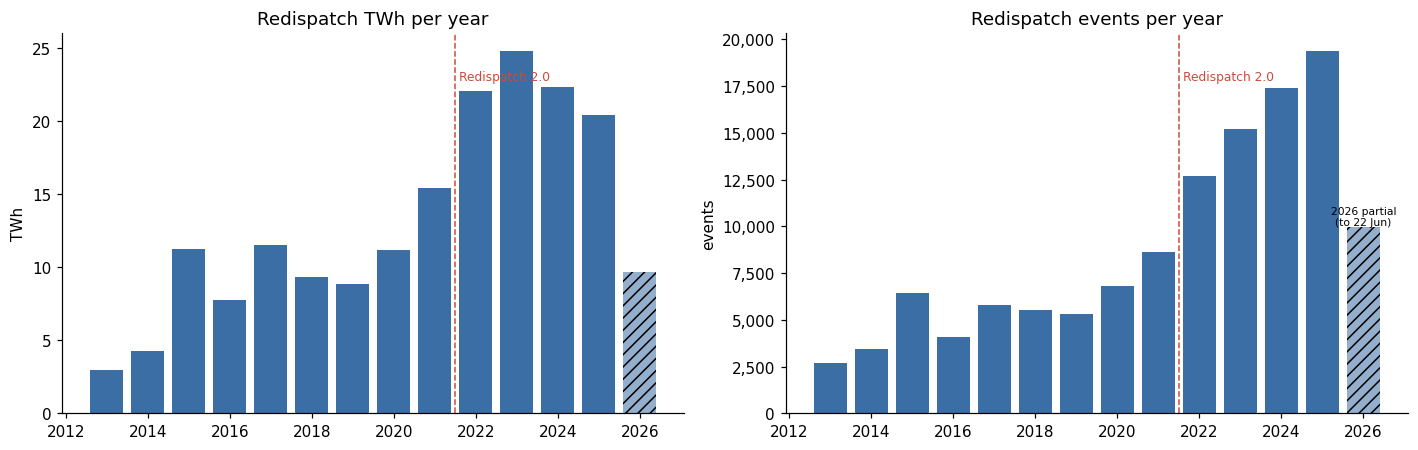

  saved figures_paper\F9_direction_and_size_over_time.png


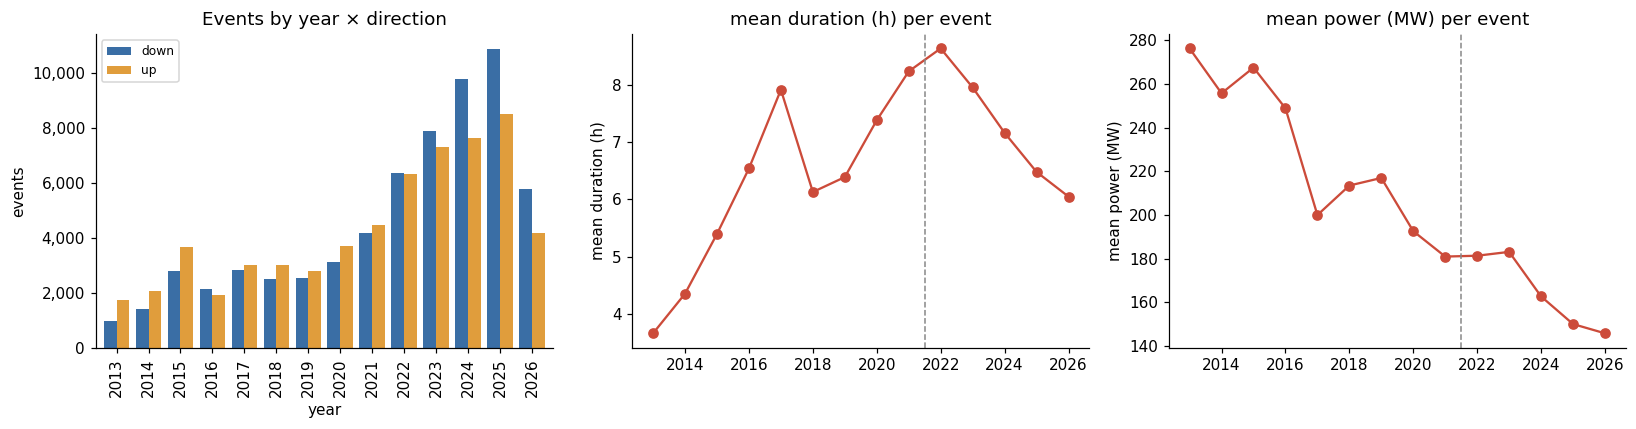

In [10]:
t = ALL.dropna(subset=['ts_start']).copy()
t['year'] = t['ts_start'].dt.year
t['dir']  = t['RICHTUNG'].map(dir_short)

yr = t.groupby('year').agg(events=('GRUND_DER_MASSNAHME','size'),
                           twh=('GESAMTE_ARBEIT_MWH', lambda s: s.abs().sum()/1e6),
                           mean_dur_h=('duration_h','mean'),
                           mean_mw=('MITTLERE_LEISTUNG_MW','mean')).round(2)
display(yr)
part = yr.index.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, lab in [(axes[0], 'twh', 'TWh'), (axes[1], 'events', 'events')]:
    bars = ax.bar(yr.index, yr[col], color='#3a6ea5')
    bars[-1].set_hatch('///'); bars[-1].set_alpha(.55)
    ax.axvline(2021.5, color='#cc4b3a', ls='--', lw=1)
    ax.annotate('Redispatch 2.0', (2021.6, yr[col].max()*0.92), fontsize=8, color='#cc4b3a')
    ax.set_ylabel(lab); ax.set_title(f'Redispatch {lab} per year'); thousands(ax)
axes[1].annotate(f'{part} partial\n(to 22 Jun)', (part, yr["events"].iloc[-1]),
                 ha='center', va='bottom', fontsize=7)
plt.tight_layout(); save(fig, 'F8_timeline_year'); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ed = t.groupby(['year','dir']).size().unstack(fill_value=0)
ed.plot.bar(ax=axes[0], color=[DIR_COLORS[c] for c in ed.columns], width=.8)
axes[0].set_title('Events by year × direction'); axes[0].set_ylabel('events'); thousands(axes[0])
axes[0].legend(title='', fontsize=8)
for ax, col, lab in [(axes[1], 'mean_dur_h', 'mean duration (h)'), (axes[2], 'mean_mw', 'mean power (MW)')]:
    ax.plot(yr.index, yr[col], marker='o', color='#cc4b3a')
    ax.axvline(2021.5, color='#888', ls='--', lw=1)
    ax.set_title(f'{lab} per event'); ax.set_ylabel(lab)
plt.tight_layout(); save(fig, 'F9_direction_and_size_over_time'); plt.show()

---
## 9. Seasonality — paper Figure 9  *(basis: ALL)*

Backs the §5.1 claim that winter months dominate and that winter events are
longer and more energy-intensive.

,events,gwh,mean_dur_h,mean_mwh
Jan,15086,26248.6,8.2,1739.9
Feb,11575,19956.9,7.9,1724.1
Mar,11548,15806.4,6.6,1368.8
Apr,11077,14691.5,6.5,1326.3
May,8945,11776.9,6.6,1316.6
Jun,8209,9686.3,6.2,1180.0
Jul,7228,9221.5,6.2,1275.8
Aug,5855,7072.2,5.9,1207.9
Sep,8668,10532.3,6.0,1215.1
Oct,11239,15816.7,6.8,1407.3



Nov-Feb: 41% of events, 48% of volume
mean event size winter 1727 MWh vs summer (May-Aug) 1245 MWh


  saved figures_paper\F10_seasonality.png


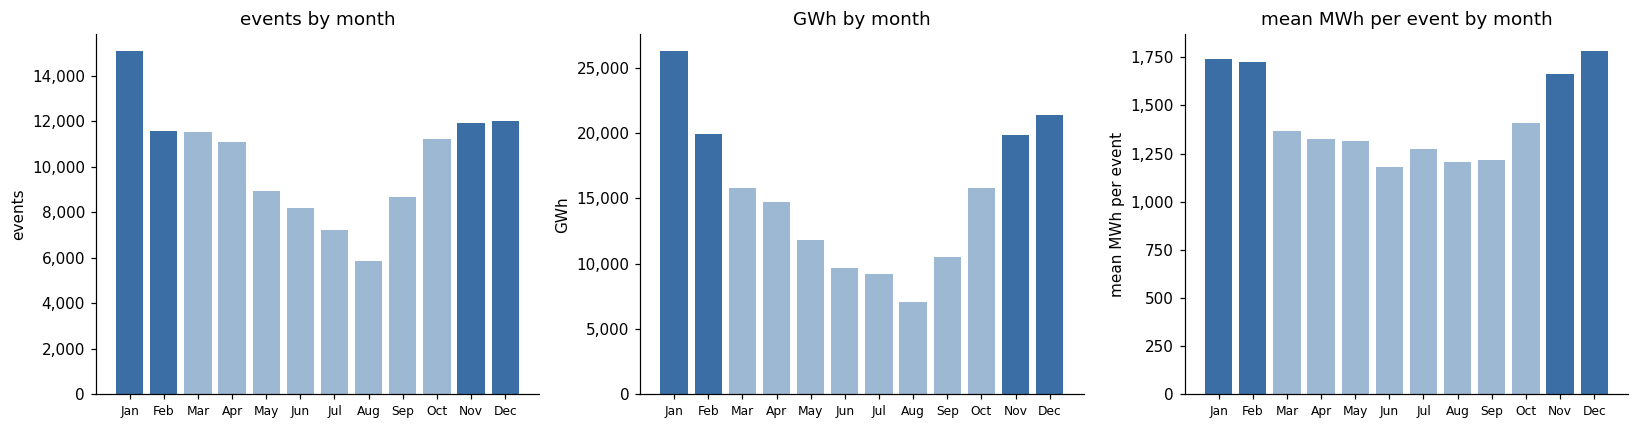

In [11]:
t['month'] = t['ts_start'].dt.month
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mo = t.groupby('month').agg(events=('GRUND_DER_MASSNAHME','size'),
                            gwh=('GESAMTE_ARBEIT_MWH', lambda s: s.abs().sum()/1e3),
                            mean_dur_h=('duration_h','mean'),
                            mean_mwh=('GESAMTE_ARBEIT_MWH', lambda s: s.abs().mean())).round(1)
mo.index = MONTHS
display(mo)
winter = mo.loc[['Nov','Dec','Jan','Feb']]
print(f'\nNov-Feb: {100*winter["events"].sum()/mo["events"].sum():.0f}% of events, '
      f'{100*winter["gwh"].sum()/mo["gwh"].sum():.0f}% of volume')
print(f'mean event size winter {winter["mean_mwh"].mean():.0f} MWh vs '
      f'summer (May-Aug) {mo.loc[["May","Jun","Jul","Aug"],"mean_mwh"].mean():.0f} MWh')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#3a6ea5' if m in ('Nov','Dec','Jan','Feb') else '#9db8d2' for m in MONTHS]
for ax, col, lab in [(axes[0],'events','events'), (axes[1],'gwh','GWh'), (axes[2],'mean_mwh','mean MWh per event')]:
    ax.bar(MONTHS, mo[col], color=colors)
    ax.set_ylabel(lab); ax.set_title(f'{lab} by month'); thousands(ax)
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout(); save(fig, 'F10_seasonality'); plt.show()

---
## 10. Fact-check table

Every checkable number from Sections 4 / 4.1 / 5.1, as printed in the draft against
the value computed above. `ok = False` means the text needs changing.

In [12]:
chk = pd.DataFrame(CLAIMS)[['section','claim','paper','computed','ok','note']]
chk['status'] = np.where(chk['ok'], 'OK', 'FIX')

def _style(r):
    return ['background-color: #ffe1e1' if not r['ok'] else '' for _ in r]

display(chk.drop(columns=['ok']).style.apply(_style, axis=1, subset=pd.IndexSlice[:, :]))

n_fix = int((~chk['ok']).sum())
print(f'\n{len(chk)} claims checked — {len(chk)-n_fix} OK, {n_fix} need fixing\n')
for _, r in chk[~chk['ok']].iterrows():
    print(f"  [{r['section']}] {r['claim']}\n      paper: {r['paper']}   computed: {r['computed']}"
          + (f"\n      -> {r['note']}" if r['note'] else ''))

chk.to_csv(FIG_DIR / 'claim_check.csv', index=False)
print(f'\nwritten: {(FIG_DIR / "claim_check.csv").relative_to(DATA_DIR)}')
print(f'figures in: {FIG_DIR.relative_to(DATA_DIR)}/')

KeyError: 'ok'


33 claims checked — 23 OK, 10 need fixing

  [4.1] "three quarters" with conf > 0.8
      paper: 75% of all events   computed: 62% of all / 73% of matched
      -> denominator must be stated: 62% of all, 73% of matched
  [4.1] excluded events
      paper: 36801   computed: 39646
      -> 36,801 is the pre-reason-filter count; 123,362-83,716 = 39,646
  [4.1] figure caption threshold
      paper: conf > 0.5   computed: conf > 0.4
      -> caption and text disagree; the values are the 0.4 ones
  [4.1] TenneT "MWh and event rates (66% and 60%)"
      paper: MWh 66 / events 60   computed: events 66 / MWh 60
      -> labels swapped in the text: 66 is events, 60 is MWh
  [5.1] North down events
      paper: 27800   computed: 27574
      -> GEO basis; on EXPORT it is 21,925
  [5.1] North down GWh
      paper: 40000   computed: 40124
      -> EXPORT: 34,856
  [5.1] North up events
      paper: 5800   computed: 5875
      -> EXPORT: 5,206
  [5.1] South up events
      paper: 25900   computed: 2